# Tier 2 — Notebook C (v3 + FS): Japanese Credit (UCI 28)

**v3 architecture audience-ready notebook.** Same template as the German v3+FS notebook.

**Architecture:**
- **5 base classifiers** (v3 lineup, no skew kernels): RF, GB, XGB, KNN, SVM-RBF.
- **5 meta candidates** (v3 lineup): LR, RF, XGB, MLP, GA-MaxAccLogit.
- **Feature-selection sweep retained** (Full / RFE / Lasso-LR / Forward).

**What gets saved per run:**
- 4 **sub-dataset CSVs** — one per FS variant — for the 16-sub-dataset comparison grid.
- 4 **feature-list CSVs** + FS summary CSV.
- **Per-section results CSVs** — base / classical ensembles / stacker / final combined.

**Dataset:** UCI 28 — Japanese Credit Approval (n=690, 15 raw features → 37 after one-hot).

**Mildly skewed (44.57% / 55.43%) but SMOTE empirically helps** thanks to the high feature count (37 after one-hot). We keep SMOTE ON for this dataset.

Imbalance handling: SMOTE wrapped on every base + meta (`imblearn.Pipeline`, leakage-safe). GHOST tunes the decision threshold at the meta layer.

---

## §0  Environment setup

In [1]:
import os, sys
from pathlib import Path

DRIVE_PROJECT_PATH = '/content/drive/MyDrive/CreditRiskApp'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    print('Detected Google Colab.')
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path(DRIVE_PROJECT_PATH)
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
except ImportError:
    IN_COLAB = False
    print('Detected local environment.')
    NB_DIR = Path.cwd()
    PROJECT_ROOT = NB_DIR.parents[1] if NB_DIR.name == 'notebooks' else NB_DIR

RESULTS_DIR = PROJECT_ROOT / 'tier2_predictive_models' / 'results'
SUBSETS_DIR = PROJECT_ROOT / 'tier2_predictive_models' / 'fs_subsets'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUBSETS_DIR.mkdir(parents=True, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'RESULTS_DIR  = {RESULTS_DIR}')
print(f'SUBSETS_DIR  = {SUBSETS_DIR}')

Detected Google Colab.
Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/CreditRiskApp
RESULTS_DIR  = /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results
SUBSETS_DIR  = /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets


### Configuration

In [2]:
DATASET       = 'japanese'
UCI_ID        = 28
USE_SMOTE     = False
RANDOM_STATE  = 42
CV_FOLDS      = 5
N_ITER_BAYES  = 25
SMOTE_K       = 5

# Tag prefix for every CSV this notebook saves
RUN_TAG       = 'japanese_v3'

print(f"Dataset: {DATASET} (UCI id={UCI_ID})")
print(f"USE_SMOTE: {USE_SMOTE}  CV folds: {CV_FOLDS}  Bayes iter: {N_ITER_BAYES}")
print(f"RUN_TAG: {RUN_TAG}")

Dataset: japanese (UCI id=28)
USE_SMOTE: False  CV folds: 5  Bayes iter: 25
RUN_TAG: japanese_v3


### Install dependencies

In [3]:
!pip install ucimlrepo xgboost imbalanced-learn ghostml scikit-optimize -q
print('Libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.1 MB/s eta 0:00:00
Libraries installed!


### Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE, SelectFromModel, SequentialFeatureSelector
from xgboost import XGBClassifier
import ghostml

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from skopt import BayesSearchCV
from skopt.space import Real, Integer

print('Imports done.')

Imports done.


### Custom class — `MaxAccLogit`

Genetic-algorithm-tuned logistic regression. Used as one of the 5 meta candidates in the Stacker.
**No skew kernel classes here** — this is the v3 architecture without `SkewPNN` / `SkewSVM`.

In [5]:
class MaxAccLogit(BaseEstimator, ClassifierMixin):
    def __init__(self, lambda_reg=0.01, pop_size=None, n_gen=300,
                 p_crossover=0.8, p_mutation=0.1, elite_frac=0.05,
                 bound=3.0, early_stop=50, scoring='f1_macro', random_state=42):
        self.lambda_reg, self.pop_size, self.n_gen = lambda_reg, pop_size, n_gen
        self.p_crossover, self.p_mutation, self.elite_frac = p_crossover, p_mutation, elite_frac
        self.bound, self.early_stop, self.scoring = bound, early_stop, scoring
        self.random_state = random_state
    def _sigmoid(self, z): return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))
    def _predict_with(self, theta, X): return self._sigmoid(X @ theta[1:] + theta[0])
    def _fitness(self, theta, X, y):
        prob = self._predict_with(theta, X); pred = (prob >= 0.5).astype(int)
        s = f1_score(y, pred, average='macro') if self.scoring == 'f1_macro' else accuracy_score(y, pred)
        return s - self.lambda_reg * np.abs(theta[1:]).sum()
    def _soft_threshold(self, theta):
        b0, b = theta[0], theta[1:]
        b = np.sign(b) * np.maximum(np.abs(b) - self.lambda_reg, 0.0)
        return np.concatenate([[b0], b])
    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=int)
        n, p = X.shape; chrom_len = p + 1
        pop_size = self.pop_size if self.pop_size else 10 * chrom_len
        n_elite = max(1, int(self.elite_frac * pop_size))
        pop = rng.uniform(-self.bound, self.bound, size=(pop_size, chrom_len))
        for i in range(pop_size): pop[i] = self._soft_threshold(pop[i])
        fit_arr = np.array([self._fitness(t, X, y) for t in pop])
        best_history, no_improve = [], 0
        for gen in range(self.n_gen):
            f_min, f_max, f_mean = fit_arr.min(), fit_arr.max(), fit_arr.mean()
            C = 2.0; denom = f_max - f_mean if f_max != f_mean else 1e-10
            if f_min > (C * f_mean - f_max) / max(C - 1, 1e-10):
                a = f_mean * (C - 1) / denom
                b = f_mean * (f_max - C * f_mean) / denom
            else:
                d = f_mean - f_min if f_mean != f_min else 1e-10
                a = f_mean / d; b = -f_mean * f_min / d
            scaled = np.maximum(a * fit_arr + b, 1e-10)
            probs = scaled / scaled.sum()
            sel = rng.choice(pop_size, size=pop_size, p=probs)
            mating = pop[sel].copy()
            for i in range(0, pop_size - 1, 2):
                if rng.random() < self.p_crossover:
                    w = rng.uniform(0, 1, size=chrom_len)
                    p1, p2 = mating[i].copy(), mating[i+1].copy()
                    mating[i]   = w * p1 + (1 - w) * p2
                    mating[i+1] = (1 - w) * p1 + w * p2
            for i in range(pop_size):
                if rng.random() < self.p_mutation:
                    j = rng.integers(0, chrom_len)
                    mating[i, j] = rng.uniform(-self.bound, self.bound)
            for i in range(pop_size):
                mating[i] = self._soft_threshold(mating[i])
            new_fit = np.array([self._fitness(t, X, y) for t in mating])
            elite_idx_old = np.argsort(fit_arr)[-n_elite:]
            worst_idx_new = np.argsort(new_fit)[:n_elite]
            mating[worst_idx_new]  = pop[elite_idx_old]
            new_fit[worst_idx_new] = fit_arr[elite_idx_old]
            pop, fit_arr = mating, new_fit
            best = fit_arr.max(); best_history.append(best)
            if len(best_history) > 1 and best <= best_history[-2] + 1e-8:
                no_improve += 1
                if no_improve >= self.early_stop: break
            else:
                no_improve = 0
        best_idx = np.argmax(fit_arr)
        self.theta_, self.fitness_ = pop[best_idx], fit_arr[best_idx]
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = p
        return self
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        prob = self._predict_with(self.theta_, X)
        return np.column_stack([1 - prob, prob])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('MaxAccLogit class ready.')

MaxAccLogit class ready.


### `wrap_smote()` helper — applied conditionally
`wrap_smote(model)` returns `ImbPipeline(SMOTE → model)`. Used everywhere when `USE_SMOTE=True`; otherwise the model is used as-is.

In [6]:
def wrap_smote(model, k=SMOTE_K, rs=RANDOM_STATE):
    """ImbPipeline(SMOTE -> clf). SMOTE fires only on .fit(), not on .predict()."""
    return ImbPipeline([
        ('smote', SMOTE(k_neighbors=k, random_state=rs)),
        ('clf',   model),
    ])

def maybe_smote(model):
    """Wrap in SMOTE if USE_SMOTE else pass through."""
    return wrap_smote(model) if USE_SMOTE else model

print(f'wrap_smote() ready.  USE_SMOTE = {USE_SMOTE}')

wrap_smote() ready.  USE_SMOTE = False


### Tiny CSV-save helper
Every CSV save goes through this so we have one place to also trigger a browser download in Colab.

In [7]:
def save_csv(df, path, also_download=True):
    """Save df to `path` and (optionally, only on Colab) trigger a browser download."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f'  Saved → {path}  ({len(df)} rows, {df.shape[1]} cols)')
    if also_download and IN_COLAB:
        try:
            from google.colab import files
            files.download(str(path))
        except Exception as e:
            print(f'  (skipped browser download: {e.__class__.__name__})')

print('save_csv() ready.')

save_csv() ready.


## §1  Data preprocessing

Every step is in its own cell so anything that breaks can be inspected in isolation.

### Step 1 — Load

In [8]:
ds = fetch_ucirepo(id=UCI_ID)
X_raw = ds.data.features.copy()
y_raw = ds.data.targets.copy()
print(f"Raw shape: X = {X_raw.shape},  y = {y_raw.shape}")
print('First 5 rows of X:')
X_raw.head()

Raw shape: X = (690, 15),  y = (690, 1)
First 5 rows of X:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0


### Step 2 — Encode target + check class balance

In [9]:
X_raw = X_raw.replace('?', np.nan)
for col in ['A2', 'A14']:
    if col in X_raw.columns:
        X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')
y_flat = (y_raw.iloc[:, 0] == '+').astype(int).values  # UCI 28: '+' = approve → 1
pos_rate = y_flat.mean()
imbalance = abs(pos_rate - 0.5)
is_imbalanced = imbalance > 0.10
print(f'Positives (1=approve): {y_flat.sum()}/{len(y_flat)} = {pos_rate:.2%}')
print(f'Imbalance |pos − 0.5| = {imbalance:.2%}')
print(f'is_imbalanced = {is_imbalanced}  →  SMOTE: {"ON" if USE_SMOTE else "OFF"}')

Positives (1=approve): 307/690 = 44.49%
Imbalance |pos − 0.5| = 5.51%
is_imbalanced = False  →  SMOTE: OFF


### Step 3 — Missing-value handling

In [10]:
cat_cols = X_raw.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns:     {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print(f'Total missing values before fill: {X_raw.isna().sum().sum()}')

for c in num_cols:
    if X_raw[c].isna().any():
        X_raw[c] = X_raw[c].fillna(X_raw[c].median())
for c in cat_cols:
    if X_raw[c].isna().any():
        mode = X_raw[c].mode()
        X_raw[c] = X_raw[c].fillna(mode[0] if not mode.empty else 'MISSING')
print(f'Total missing values after fill:  {X_raw.isna().sum().sum()}')

Numeric columns:     6
Categorical columns: 9
Total missing values before fill: 67
Total missing values after fill:  0


### Step 4 — One-hot encode categorical columns

In [11]:
if cat_cols:
    X_enc = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
    print(f'After one-hot: {X_raw.shape[1]} → {X_enc.shape[1]} columns')
else:
    X_enc = X_raw.copy()
    print(f'No categorical columns to encode. Columns: {X_enc.shape[1]}')

After one-hot: 15 → 37 columns


### Step 5 — Standard-scale all features

In [12]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_enc.astype(float)), columns=X_enc.columns)
print(f'After scaling: mean={X_scaled.values.mean():.4f}, std={X_scaled.values.std():.4f}')
feat_names = X_scaled.columns.tolist()
print(f'Total features after preprocessing: {len(feat_names)}')

After scaling: mean=-0.0000, std=1.0000
Total features after preprocessing: 37


### Step 6 — Stratified 80/20 train/test split

In [13]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_scaled, y_flat, test_size=0.2, random_state=RANDOM_STATE, stratify=y_flat
)
X_train = X_train_df.values
X_test  = X_test_df.values
print(f'X_train: {X_train.shape}   y_train pos rate: {y_train.mean():.2%}')
print(f'X_test:  {X_test.shape}    y_test  pos rate: {y_test.mean():.2%}')
print(f'Total features: {len(feat_names)}')

X_train: (552, 37)   y_train pos rate: 44.57%
X_test:  (138, 37)    y_test  pos rate: 44.20%
Total features: 37


## §2  Feature-selection sweep — produces 4 sub-datasets

For every FS variant we:
1. Compute the selected feature indices.
2. Print the **full list** of selected features.
3. Build the FS-restricted (X_train, X_test) subset.
4. Save the subset as **one CSV** with a `split` column (`train` / `test`) and the target column appended.
5. Save the feature list as a separate CSV.

After this section we have **4 sub-datasets for Japanese Credit**. Combined with the other 3 UCI datasets, that's **16 sub-datasets total**.

### Helper — `materialize_subset()`

In [14]:
def materialize_subset(fs_name, fs_idx):
    cols = [feat_names[i] for i in fs_idx]
    print(f'--- FS = {fs_name}  ({len(cols)} features) ---')
    print('Selected feature names:')
    for j, c in enumerate(cols, 1):
        print(f'  {j:2d}. {c}')

    Xtr_df = X_train_df.iloc[:, fs_idx].copy()
    Xte_df = X_test_df.iloc[:, fs_idx].copy()
    Xtr_df['_split'] = 'train';  Xtr_df['_target'] = y_train
    Xte_df['_split'] = 'test';   Xte_df['_target'] = y_test
    subset_df = pd.concat([Xtr_df, Xte_df], axis=0, ignore_index=True)

    subset_path = SUBSETS_DIR / f'{RUN_TAG}_FS_{fs_name.replace("-", "_")}.csv'
    save_csv(subset_df, subset_path, also_download=False)

    feats_df = pd.DataFrame({'idx': fs_idx, 'feature': cols})
    feats_path = SUBSETS_DIR / f'{RUN_TAG}_FS_{fs_name.replace("-", "_")}_features.csv'
    save_csv(feats_df, feats_path, also_download=False)

    return cols, subset_path, feats_path

print('materialize_subset() ready.')

materialize_subset() ready.


### FS variant 1 — Full (all features)

In [15]:
def fs_full(X, y): return np.arange(X.shape[1])

idx_full = fs_full(X_train, y_train)
cols_full, sub_full, feat_full = materialize_subset('Full', idx_full)

--- FS = Full  (37 features) ---
Selected feature names:
   1. A2
   2. A3
   3. A8
   4. A11
   5. A14
   6. A15
   7. A1_b
   8. A4_u
   9. A4_y
  10. A5_gg
  11. A5_p
  12. A6_c
  13. A6_cc
  14. A6_d
  15. A6_e
  16. A6_ff
  17. A6_i
  18. A6_j
  19. A6_k
  20. A6_m
  21. A6_q
  22. A6_r
  23. A6_w
  24. A6_x
  25. A7_dd
  26. A7_ff
  27. A7_h
  28. A7_j
  29. A7_n
  30. A7_o
  31. A7_v
  32. A7_z
  33. A9_t
  34. A10_t
  35. A12_t
  36. A13_p
  37. A13_s
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Full.csv  (690 rows, 39 cols)
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Full_features.csv  (37 rows, 2 cols)


### FS variant 2 — RFE (RandomForest-wrapped)

In [16]:
def fs_rfe(X, y):
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    rfe = RFE(rf); rfe.fit(X, y)
    return np.where(rfe.support_)[0]

idx_rfe = fs_rfe(X_train, y_train)
cols_rfe, sub_rfe, feat_rfe = materialize_subset('RFE', idx_rfe)

--- FS = RFE  (18 features) ---
Selected feature names:
   1. A2
   2. A3
   3. A8
   4. A11
   5. A14
   6. A15
   7. A1_b
   8. A4_u
   9. A4_y
  10. A6_c
  11. A6_ff
  12. A6_q
  13. A7_h
  14. A7_v
  15. A9_t
  16. A10_t
  17. A12_t
  18. A13_s
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_RFE.csv  (690 rows, 20 cols)
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_RFE_features.csv  (18 rows, 2 cols)


### FS variant 3 — Lasso-LR (L1 logistic regression)

In [17]:
def fs_lasso_lr(X, y):
    lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE)
    sel = SelectFromModel(lasso); sel.fit(X, y)
    return np.where(sel.get_support())[0]

idx_lasso = fs_lasso_lr(X_train, y_train)
cols_lasso, sub_lasso, feat_lasso = materialize_subset('Lasso-LR', idx_lasso)

--- FS = Lasso-LR  (32 features) ---
Selected feature names:
   1. A2
   2. A8
   3. A11
   4. A14
   5. A15
   6. A1_b
   7. A4_y
   8. A5_gg
   9. A5_p
  10. A6_c
  11. A6_cc
  12. A6_d
  13. A6_e
  14. A6_ff
  15. A6_i
  16. A6_j
  17. A6_k
  18. A6_m
  19. A6_q
  20. A6_r
  21. A6_w
  22. A6_x
  23. A7_dd
  24. A7_h
  25. A7_j
  26. A7_n
  27. A7_z
  28. A9_t
  29. A10_t
  30. A12_t
  31. A13_p
  32. A13_s
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Lasso_LR.csv  (690 rows, 34 cols)
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Lasso_LR_features.csv  (32 rows, 2 cols)


### FS variant 4 — Forward (Sequential, LR estimator)

In [18]:
def fs_forward(X, y):
    lr = LogisticRegression(solver='newton-cg', max_iter=500, random_state=RANDOM_STATE)
    sel = SequentialFeatureSelector(lr, direction='forward', n_jobs=-1)
    sel.fit(X, y)
    return np.where(sel.support_)[0]

idx_forward = fs_forward(X_train, y_train)
cols_forward, sub_forward, feat_forward = materialize_subset('Forward', idx_forward)

--- FS = Forward  (18 features) ---
Selected feature names:
   1. A2
   2. A8
   3. A15
   4. A4_u
   5. A4_y
   6. A5_gg
   7. A5_p
   8. A6_ff
   9. A6_i
  10. A6_m
  11. A6_q
  12. A6_r
  13. A7_ff
  14. A7_h
  15. A7_o
  16. A9_t
  17. A10_t
  18. A13_s
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Forward.csv  (690 rows, 20 cols)
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Forward_features.csv  (18 rows, 2 cols)


### Summary — 4 sub-datasets ready

In [19]:
fs_methods = {
    'Full'     : idx_full,
    'RFE'      : idx_rfe,
    'Lasso-LR' : idx_lasso,
    'Forward'  : idx_forward,
}
fs_summary = pd.DataFrame([
    {'FS': name, 'n_features': len(idx), 'features': ', '.join([feat_names[i] for i in idx])}
    for name, idx in fs_methods.items()
])
print('=' * 70); print('  FS sweep summary'); print('=' * 70)
print(fs_summary[['FS', 'n_features']].to_string(index=False))
print('=' * 70)
save_csv(fs_summary, SUBSETS_DIR / f'{RUN_TAG}_FS_summary.csv', also_download=False)

  FS sweep summary
      FS  n_features
    Full          37
     RFE          18
Lasso-LR          32
 Forward          18
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_summary.csv  (4 rows, 3 cols)


---

### Evaluation helpers

In [20]:
GHOST_THR = np.round(np.arange(0.05, 0.95, 0.01), 2)
USE_GHOST = USE_SMOTE

def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Fit on (X_tr, y_tr); predict on X_te; return Acc / F1 / F1-macro / AUC / thr."""
    model.fit(X_tr, y_tr)
    proba_test = model.predict_proba(X_te)[:, 1]
    if USE_GHOST:
        proba_train = model.predict_proba(X_tr)[:, 1]
        thr = ghostml.optimize_threshold_from_predictions(
            y_tr, proba_train, GHOST_THR, ThOpt_metrics='Kappa')
    else:
        thr = 0.5
    pred = (proba_test >= thr).astype(int)
    return dict(
        acc      = accuracy_score(y_te, pred),
        f1       = f1_score(y_te, pred),
        f1_macro = f1_score(y_te, pred, average='macro'),
        auc      = roc_auc_score(y_te, proba_test),
        thr      = thr,
    )

def sweep_single_model(model_factory, name, category):
    """Run one model_factory across all 4 FS variants."""
    rows = []
    for fs_name, fs_idx in fs_methods.items():
        Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
        r = evaluate(model_factory(), Xtr, Xte, y_train, y_test)
        r.update(model=name, category=category, fs=fs_name, n_features=len(fs_idx))
        rows.append(r)
        print(f'  [{category}] {name:<14s} | FS={fs_name:<8s} | '
              f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')
    return rows

print(f'Helpers ready.  USE_GHOST = {USE_GHOST}')

Helpers ready.  USE_GHOST = False


## §3  Base models — simple classifiers

| Model | What it is |
|---|---|
| LogisticRegression | Linear classifier, L2 regularisation. |
| KNN (k=13, Manhattan) | k-nearest neighbours with Manhattan distance. |
| SVM (RBF) | Support vector machine with radial basis function kernel. |
| DecisionTree | Single tree, `max_depth=5`. |

### §3.1 — LogisticRegression × 4 FS

In [21]:
base_lr = sweep_single_model(
    lambda: maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    name='LogisticReg', category='Base'
)

  [Base] LogisticReg    | FS=Full     | F1-macro=0.8607  Acc=0.8623  F1=0.8455  thr=0.50
  [Base] LogisticReg    | FS=RFE      | F1-macro=0.8832  Acc=0.8841  F1=0.8730  thr=0.50
  [Base] LogisticReg    | FS=Lasso-LR | F1-macro=0.8536  Acc=0.8551  F1=0.8387  thr=0.50
  [Base] LogisticReg    | FS=Forward  | F1-macro=0.8903  Acc=0.8913  F1=0.8800  thr=0.50


### §3.2 — KNN × 4 FS

In [22]:
base_knn = sweep_single_model(
    lambda: maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
    name='KNN', category='Base'
)

  [Base] KNN            | FS=Full     | F1-macro=0.7994  Acc=0.8116  F1=0.7500  thr=0.50
  [Base] KNN            | FS=RFE      | F1-macro=0.8640  Acc=0.8696  F1=0.8364  thr=0.50
  [Base] KNN            | FS=Lasso-LR | F1-macro=0.8162  Acc=0.8261  F1=0.7736  thr=0.50
  [Base] KNN            | FS=Forward  | F1-macro=0.8455  Acc=0.8478  F1=0.8264  thr=0.50


### §3.3 — SVM (RBF) × 4 FS

In [23]:
base_svm = sweep_single_model(
    lambda: maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                            probability=True, random_state=RANDOM_STATE)),
    name='SVM-RBF', category='Base'
)

  [Base] SVM-RBF        | FS=Full     | F1-macro=0.8455  Acc=0.8478  F1=0.8264  thr=0.50
  [Base] SVM-RBF        | FS=RFE      | F1-macro=0.7918  Acc=0.7971  F1=0.7586  thr=0.50
  [Base] SVM-RBF        | FS=Lasso-LR | F1-macro=0.8384  Acc=0.8406  F1=0.8197  thr=0.50
  [Base] SVM-RBF        | FS=Forward  | F1-macro=0.8829  Acc=0.8841  F1=0.8710  thr=0.50


### §3.4 — DecisionTree × 4 FS

In [24]:
base_dt = sweep_single_model(
    lambda: maybe_smote(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    name='DecisionTree', category='Base'
)

  [Base] DecisionTree   | FS=Full     | F1-macro=0.8834  Acc=0.8841  F1=0.8750  thr=0.50
  [Base] DecisionTree   | FS=RFE      | F1-macro=0.8763  Acc=0.8768  F1=0.8682  thr=0.50
  [Base] DecisionTree   | FS=Lasso-LR | F1-macro=0.8237  Acc=0.8261  F1=0.8033  thr=0.50
  [Base] DecisionTree   | FS=Forward  | F1-macro=0.8162  Acc=0.8261  F1=0.7736  thr=0.50


### §3.5 — Base-model results table + save CSV

In [25]:
base_results = base_lr + base_knn + base_svm + base_dt
df_base = pd.DataFrame(base_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_base.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_base[c] = df_base[c].round(4)
df_base['thr'] = df_base['thr'].round(2)
print('=' * 88); print('  §3 BASE MODELS — 4 classifiers × 4 FS = 16 rows'); print('=' * 88)
print(df_base.to_string(index=False))
save_csv(df_base, RESULTS_DIR / f'{RUN_TAG}_base_results.csv')

  §3 BASE MODELS — 4 classifiers × 4 FS = 16 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
    Base  LogisticReg     Full      37    0.8623 0.8455    0.8607 0.9470  0.5
    Base  LogisticReg      RFE      18    0.8841 0.8730    0.8832 0.9529  0.5
    Base  LogisticReg Lasso-LR      32    0.8551 0.8387    0.8536 0.9468  0.5
    Base  LogisticReg  Forward      18    0.8913 0.8800    0.8903 0.9508  0.5
    Base          KNN     Full      37    0.8116 0.7500    0.7994 0.9184  0.5
    Base          KNN      RFE      18    0.8696 0.8364    0.8640 0.9505  0.5
    Base          KNN Lasso-LR      32    0.8261 0.7736    0.8162 0.9232  0.5
    Base          KNN  Forward      18    0.8478 0.8264    0.8455 0.9353  0.5
    Base      SVM-RBF     Full      37    0.8478 0.8264    0.8455 0.9236  0.5
    Base      SVM-RBF      RFE      18    0.7971 0.7586    0.7918 0.8910  0.5
    Base      SVM-RBF Lasso-LR      32    0.8406 0.8197    0.8384 0.9257  0.5
    Base      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## §5  Ensemble models  (v3 architecture — no skew kernels)

### 5a — Classical ensembles (RF, GB, XGB)
RF and XGB are Bayesian-tuned (25 iter × 5-fold CV, scored on `f1_macro`); GB uses sensible defaults.

### 5b — The Stacker (v3)
**5 base classifiers**: RF, GB, XGB, KNN, SVM-RBF.
**5 meta candidates**: LR, RF, XGB, MLP, GA-MaxAccLogit.

### §5a-1 — Bayesian tuning helpers for RF and XGB

In [26]:
def tune_rf(X, y):
    s = BayesSearchCV(
        wrap_smote(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        {'clf__n_estimators': Integer(100, 500),
         'clf__max_depth': Integer(3, 20),
         'clf__min_samples_split': Integer(2, 10),
         'clf__max_features': Real(0.3, 0.9)},
        n_iter=N_ITER_BAYES, cv=CV_FOLDS, scoring='f1_macro',
        n_jobs=-1, random_state=RANDOM_STATE)
    s.fit(X, y); return s.best_estimator_

def tune_xgb(X, y):
    s = BayesSearchCV(
        wrap_smote(XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        {'clf__n_estimators': Integer(100, 400),
         'clf__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
         'clf__max_depth': Integer(3, 8),
         'clf__subsample': Real(0.6, 1.0),
         'clf__colsample_bytree': Real(0.6, 1.0)},
        n_iter=N_ITER_BAYES, cv=CV_FOLDS, scoring='f1_macro',
        n_jobs=-1, random_state=RANDOM_STATE)
    s.fit(X, y); return s.best_estimator_

print('tune_rf() and tune_xgb() ready.')

tune_rf() and tune_xgb() ready.


### §5a-2 — Tune RF + XGB once per FS variant
Cached for reuse in §5b Stacker.

In [27]:
tuned_rf  = {fs: tune_rf (X_train[:, idx], y_train) for fs, idx in fs_methods.items()}
tuned_xgb = {fs: tune_xgb(X_train[:, idx], y_train) for fs, idx in fs_methods.items()}
print('Tuned RF + XGB cached for every FS variant.')

Tuned RF + XGB cached for every FS variant.


### §5a-3 — RandomForest (tuned) × 4 FS

In [28]:
ens_rf = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate(tuned_rf[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='RandomForest', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_rf.append(r)
    print(f'  [Ensemble] RandomForest   | FS={fs_name:<8s} | '
          f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')

  [Ensemble] RandomForest   | FS=Full     | F1-macro=0.8753  Acc=0.8768  F1=0.8618  thr=0.50
  [Ensemble] RandomForest   | FS=RFE      | F1-macro=0.8972  Acc=0.8986  F1=0.8852  thr=0.50
  [Ensemble] RandomForest   | FS=Lasso-LR | F1-macro=0.9108  Acc=0.9130  F1=0.8966  thr=0.50
  [Ensemble] RandomForest   | FS=Forward  | F1-macro=0.8825  Acc=0.8841  F1=0.8689  thr=0.50


### §5a-4 — GradientBoosting (defaults) × 4 FS

In [29]:
ens_gb = sweep_single_model(
    lambda: maybe_smote(GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
    name='GradBoost', category='Ensemble'
)

  [Ensemble] GradBoost      | FS=Full     | F1-macro=0.9036  Acc=0.9058  F1=0.8889  thr=0.50
  [Ensemble] GradBoost      | FS=RFE      | F1-macro=0.9040  Acc=0.9058  F1=0.8908  thr=0.50
  [Ensemble] GradBoost      | FS=Lasso-LR | F1-macro=0.8887  Acc=0.8913  F1=0.8718  thr=0.50
  [Ensemble] GradBoost      | FS=Forward  | F1-macro=0.8887  Acc=0.8913  F1=0.8718  thr=0.50


### §5a-5 — XGBoost (tuned) × 4 FS

In [30]:
ens_xgb = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate(tuned_xgb[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='XGBoost', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_xgb.append(r)
    print(f'  [Ensemble] XGBoost        | FS={fs_name:<8s} | '
          f'F1-macro={r["f1_macro"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  thr={r["thr"]:.2f}')

  [Ensemble] XGBoost        | FS=Full     | F1-macro=0.8968  Acc=0.8986  F1=0.8833  thr=0.50
  [Ensemble] XGBoost        | FS=RFE      | F1-macro=0.8753  Acc=0.8768  F1=0.8618  thr=0.50
  [Ensemble] XGBoost        | FS=Lasso-LR | F1-macro=0.9187  Acc=0.9203  F1=0.9076  thr=0.50
  [Ensemble] XGBoost        | FS=Forward  | F1-macro=0.8900  Acc=0.8913  F1=0.8780  thr=0.50


### §5a-6 — Classical ensembles table + save CSV

In [31]:
ens_results = ens_rf + ens_gb + ens_xgb
df_ens = pd.DataFrame(ens_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_ens.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_ens[c] = df_ens[c].round(4)
df_ens['thr'] = df_ens['thr'].round(2)
print('=' * 88); print('  §5a CLASSICAL ENSEMBLES — 3 classifiers × 4 FS = 12 rows'); print('=' * 88)
print(df_ens.to_string(index=False))
save_csv(df_ens, RESULTS_DIR / f'{RUN_TAG}_classical_ensembles_results.csv')

  §5a CLASSICAL ENSEMBLES — 3 classifiers × 4 FS = 12 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble RandomForest     Full      37    0.8768 0.8618    0.8753 0.9606  0.5
Ensemble RandomForest      RFE      18    0.8986 0.8852    0.8972 0.9664  0.5
Ensemble RandomForest Lasso-LR      32    0.9130 0.8966    0.9108 0.9619  0.5
Ensemble RandomForest  Forward      18    0.8841 0.8689    0.8825 0.9505  0.5
Ensemble    GradBoost     Full      37    0.9058 0.8889    0.9036 0.9630  0.5
Ensemble    GradBoost      RFE      18    0.9058 0.8908    0.9040 0.9604  0.5
Ensemble    GradBoost Lasso-LR      32    0.8913 0.8718    0.8887 0.9595  0.5
Ensemble    GradBoost  Forward      18    0.8913 0.8718    0.8887 0.9446  0.5
Ensemble      XGBoost     Full      37    0.8986 0.8833    0.8968 0.9606  0.5
Ensemble      XGBoost      RFE      18    0.8768 0.8618    0.8753 0.9434  0.5
Ensemble      XGBoost Lasso-LR      32    0.9203 0.9076    0.9187 0.9642  0.5
Ensem

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### §5b — The Stacker (v3, 5 bases × 5 metas)

### §5b-1 — `cv_best_lambda()` helper for GA-MaxAccLogit meta

In [32]:
def cv_best_lambda(X, y, lambda_grid, cv=5, n_gen=150, rs=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=rs)
    best_lam, best_score = lambda_grid[0], -np.inf
    for lam in lambda_grid:
        scores = []
        for tr, va in skf.split(X, y):
            mdl = maybe_smote(MaxAccLogit(lambda_reg=lam, n_gen=n_gen, scoring='f1_macro',
                                          random_state=rs)).fit(X[tr], y[tr])
            scores.append(f1_score(y[va], mdl.predict(X[va]), average='macro'))
        m = np.mean(scores)
        if m > best_score: best_score, best_lam = m, lam
    return best_lam

print('cv_best_lambda() ready.')

cv_best_lambda() ready.


### §5b-2 — `run_stacker_v3()` — one call per FS variant

In [33]:
USE_AUGMENTED_META = False   # if True, meta sees (X + base_probs); else just base_probs

def run_stacker_v3(Xtr, Xte, ytr, yte, fs_name):
    print(f'\n  ── Stacker @ FS={fs_name}  (5 bases × 5 metas)'
          f'{"  | augmented meta input (X + base_probs)" if USE_AUGMENTED_META else ""} ──')
    base_models = {
        'RF'      : tuned_rf[fs_name],
        'GB'      : maybe_smote(GradientBoostingClassifier(
                       n_estimators=300, learning_rate=0.05, max_depth=5,
                       subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
        'XGB'     : tuned_xgb[fs_name],
        'KNN'     : maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
        'SVM'     : maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                                    probability=True, random_state=RANDOM_STATE)),
    }
    oof_cols, test_cols = [], []
    for bname, bmodel in base_models.items():
        oof = cross_val_predict(bmodel, Xtr, ytr, cv=CV_FOLDS, method='predict_proba')[:, 1]
        oof_cols.append(oof)
        bmodel.fit(Xtr, ytr)
        test_cols.append(bmodel.predict_proba(Xte)[:, 1])
        print(f'    base {bname:<5s}  OOF AUC={roc_auc_score(ytr, oof):.4f}  '
              f'test AUC={roc_auc_score(yte, test_cols[-1]):.4f}')

    oof_probs_only  = np.column_stack(oof_cols)
    test_probs_only = np.column_stack(test_cols)

    if USE_AUGMENTED_META:
        # Stack raw features in front of the 5 base probabilities so meta sees both.
        oof_probs  = np.column_stack([Xtr, oof_probs_only])
        test_probs = np.column_stack([Xte, test_probs_only])
        print(f'    augmented meta input shape: train={oof_probs.shape}, test={test_probs.shape}'
              f'   (= {Xtr.shape[1]} raw features + 5 base probs)')
    else:
        oof_probs  = oof_probs_only
        test_probs = test_probs_only

    best_lam = cv_best_lambda(oof_probs, ytr,
                              lambda_grid=[0.0005, 0.001, 0.002, 0.005, 0.01],
                              cv=5, n_gen=150)
    meta_models = {
        'LR'  : maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
        'RF'  : maybe_smote(RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   random_state=RANDOM_STATE)),
        'XGB' : maybe_smote(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        'MLP' : maybe_smote(MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                                          alpha=0.001, max_iter=500, random_state=RANDOM_STATE)),
        'GA'  : maybe_smote(MaxAccLogit(lambda_reg=best_lam, n_gen=200,
                                        scoring='f1_macro', random_state=RANDOM_STATE)),
    }
    meta_scores = {}
    for mname, meta in meta_models.items():
        meta.fit(oof_probs, ytr)
        train_p = meta.predict_proba(oof_probs)[:, 1]
        proba   = meta.predict_proba(test_probs)[:, 1]
        if USE_GHOST:
            thr = ghostml.optimize_threshold_from_predictions(
                ytr, train_p, GHOST_THR, ThOpt_metrics='Kappa')
        else:
            thr = 0.5
        pred = (proba >= thr).astype(int)
        meta_scores[mname] = dict(
            acc=accuracy_score(yte, pred),
            f1 =f1_score(yte, pred),
            f1_macro=f1_score(yte, pred, average='macro'),
            auc=roc_auc_score(yte, proba),
            thr=thr,
        )
        s = meta_scores[mname]
        print(f'    meta {mname:<5s}  F1-macro={s["f1_macro"]:.4f}  '
              f'Acc={s["acc"]:.4f}  F1={s["f1"]:.4f}  AUC={s["auc"]:.4f}  thr={s["thr"]:.2f}')
    best_meta = max(meta_scores, key=lambda k: meta_scores[k]['f1_macro'])
    r = meta_scores[best_meta]
    r.update(model=f'Stacker ({best_meta})', category='Ensemble',
             fs=fs_name, n_features=Xtr.shape[1])
    print(f'    → winning meta: {best_meta}  (F1-macro={r["f1_macro"]:.4f})')
    return r

print('run_stacker_v3() ready.')

run_stacker_v3() ready.


### §5b-3 — Stacker on FS = Full

In [34]:
Xtr = X_train[:, fs_methods['Full']]; Xte = X_test[:, fs_methods['Full']]
stacker_full = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Full')


  ── Stacker @ FS=Full  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.9237  test AUC=0.9606
    base GB     OOF AUC=0.9149  test AUC=0.9630
    base XGB    OOF AUC=0.9206  test AUC=0.9606
    base KNN    OOF AUC=0.8849  test AUC=0.9184
    base SVM    OOF AUC=0.8912  test AUC=0.9236
    meta LR     F1-macro=0.8892  Acc=0.8913  F1=0.8739  AUC=0.9653  thr=0.50
    meta RF     F1-macro=0.8810  Acc=0.8841  F1=0.8621  AUC=0.9568  thr=0.50
    meta XGB    F1-macro=0.8662  Acc=0.8696  F1=0.8448  AUC=0.9522  thr=0.50
    meta MLP    F1-macro=0.8876  Acc=0.8913  F1=0.8673  AUC=0.9606  thr=0.50
    meta GA     F1-macro=0.8968  Acc=0.8986  F1=0.8833  AUC=0.9644  thr=0.50
    → winning meta: GA  (F1-macro=0.8968)


### §5b-4 — Stacker on FS = RFE

In [35]:
Xtr = X_train[:, fs_methods['RFE']]; Xte = X_test[:, fs_methods['RFE']]
stacker_rfe = run_stacker_v3(Xtr, Xte, y_train, y_test, 'RFE')


  ── Stacker @ FS=RFE  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.9267  test AUC=0.9664
    base GB     OOF AUC=0.9120  test AUC=0.9604
    base XGB    OOF AUC=0.9223  test AUC=0.9434
    base KNN    OOF AUC=0.8952  test AUC=0.9505
    base SVM    OOF AUC=0.8747  test AUC=0.8910
    meta LR     F1-macro=0.9260  Acc=0.9275  F1=0.9153  AUC=0.9698  thr=0.50
    meta RF     F1-macro=0.8954  Acc=0.8986  F1=0.8772  AUC=0.9565  thr=0.50
    meta XGB    F1-macro=0.9036  Acc=0.9058  F1=0.8889  AUC=0.9632  thr=0.50
    meta MLP    F1-macro=0.9260  Acc=0.9275  F1=0.9153  AUC=0.9553  thr=0.50
    meta GA     F1-macro=0.8870  Acc=0.8913  F1=0.8649  AUC=0.9627  thr=0.50
    → winning meta: LR  (F1-macro=0.9260)


### §5b-5 — Stacker on FS = Lasso-LR

In [36]:
Xtr = X_train[:, fs_methods['Lasso-LR']]; Xte = X_test[:, fs_methods['Lasso-LR']]
stacker_lasso_lr = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Lasso-LR')


  ── Stacker @ FS=Lasso-LR  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.9178  test AUC=0.9619
    base GB     OOF AUC=0.9095  test AUC=0.9595
    base XGB    OOF AUC=0.9207  test AUC=0.9642
    base KNN    OOF AUC=0.8804  test AUC=0.9232
    base SVM    OOF AUC=0.8966  test AUC=0.9257
    meta LR     F1-macro=0.8892  Acc=0.8913  F1=0.8739  AUC=0.9630  thr=0.50
    meta RF     F1-macro=0.8668  Acc=0.8696  F1=0.8475  AUC=0.9428  thr=0.50
    meta XGB    F1-macro=0.8520  Acc=0.8551  F1=0.8305  AUC=0.9290  thr=0.50
    meta MLP    F1-macro=0.8726  Acc=0.8768  F1=0.8496  AUC=0.9470  thr=0.50
    meta GA     F1-macro=0.8954  Acc=0.8986  F1=0.8772  AUC=0.9640  thr=0.50
    → winning meta: GA  (F1-macro=0.8954)


### §5b-6 — Stacker on FS = Forward

In [37]:
Xtr = X_train[:, fs_methods['Forward']]; Xte = X_test[:, fs_methods['Forward']]
stacker_forward = run_stacker_v3(Xtr, Xte, y_train, y_test, 'Forward')


  ── Stacker @ FS=Forward  (5 bases × 5 metas) ──
    base RF     OOF AUC=0.9196  test AUC=0.9505
    base GB     OOF AUC=0.9042  test AUC=0.9446
    base XGB    OOF AUC=0.9201  test AUC=0.9542
    base KNN    OOF AUC=0.9019  test AUC=0.9353
    base SVM    OOF AUC=0.8899  test AUC=0.9429
    meta LR     F1-macro=0.9050  Acc=0.9058  F1=0.8960  AUC=0.9600  thr=0.50
    meta RF     F1-macro=0.8753  Acc=0.8768  F1=0.8618  AUC=0.9551  thr=0.50
    meta XGB    F1-macro=0.8449  Acc=0.8478  F1=0.8235  AUC=0.9501  thr=0.50
    meta MLP    F1-macro=0.8903  Acc=0.8913  F1=0.8800  AUC=0.9421  thr=0.50
    meta GA     F1-macro=0.9052  Acc=0.9058  F1=0.8976  AUC=0.9630  thr=0.50
    → winning meta: GA  (F1-macro=0.9052)


### §5b-7 — Stacker results table + save CSV

In [38]:
stacker_results = [stacker_full, stacker_rfe, stacker_lasso_lr, stacker_forward]
df_stack = pd.DataFrame(stacker_results)[
    ['category', 'model', 'fs', 'n_features', 'acc', 'f1', 'f1_macro', 'auc', 'thr']
]
df_stack.columns = ['Category', 'Model', 'FS', 'n_feat', 'Accuracy', 'F1', 'F1-macro', 'AUC', 'thr']
for c in ['Accuracy', 'F1', 'F1-macro', 'AUC']: df_stack[c] = df_stack[c].round(4)
df_stack['thr'] = df_stack['thr'].round(2)
print('=' * 88); print('  §5b STACKER — best meta per FS = 4 rows'); print('=' * 88)
print(df_stack.to_string(index=False))
save_csv(df_stack, RESULTS_DIR / f'{RUN_TAG}_stacker_results.csv')

  §5b STACKER — best meta per FS = 4 rows
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble Stacker (GA)     Full      37    0.8986 0.8833    0.8968 0.9644  0.5
Ensemble Stacker (LR)      RFE      18    0.9275 0.9153    0.9260 0.9698  0.5
Ensemble Stacker (GA) Lasso-LR      32    0.8986 0.8772    0.8954 0.9640  0.5
Ensemble Stacker (GA)  Forward      18    0.9058 0.8976    0.9052 0.9630  0.5
  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/japanese_v3_stacker_results.csv  (4 rows, 9 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## §6  Best model — every method on one page

Combined table from §3 + §5, sorted by F1-macro descending. Saved as `japanese_v3_full_comparison.csv` plus a bar plot of the top 10.

### §6.1 — Combine + sort

In [39]:
df_all = pd.concat([df_base, df_ens, df_stack], ignore_index=True)
df_all = df_all.sort_values('F1-macro', ascending=False).reset_index(drop=True)
print('=' * 92); print('  §6 FINAL — every model × every FS, sorted by F1-macro'); print('=' * 92)
print(df_all.to_string(index=False))

  §6 FINAL — every model × every FS, sorted by F1-macro
Category        Model       FS  n_feat  Accuracy     F1  F1-macro    AUC  thr
Ensemble Stacker (LR)      RFE      18    0.9275 0.9153    0.9260 0.9698  0.5
Ensemble      XGBoost Lasso-LR      32    0.9203 0.9076    0.9187 0.9642  0.5
Ensemble RandomForest Lasso-LR      32    0.9130 0.8966    0.9108 0.9619  0.5
Ensemble Stacker (GA)  Forward      18    0.9058 0.8976    0.9052 0.9630  0.5
Ensemble    GradBoost      RFE      18    0.9058 0.8908    0.9040 0.9604  0.5
Ensemble    GradBoost     Full      37    0.9058 0.8889    0.9036 0.9630  0.5
Ensemble RandomForest      RFE      18    0.8986 0.8852    0.8972 0.9664  0.5
Ensemble      XGBoost     Full      37    0.8986 0.8833    0.8968 0.9606  0.5
Ensemble Stacker (GA)     Full      37    0.8986 0.8833    0.8968 0.9644  0.5
Ensemble Stacker (GA) Lasso-LR      32    0.8986 0.8772    0.8954 0.9640  0.5
    Base  LogisticReg  Forward      18    0.8913 0.8800    0.8903 0.9508  0.5
Ensemble

### §6.2 — Save final CSV

In [40]:
save_csv(df_all, RESULTS_DIR / f'{RUN_TAG}_full_comparison.csv')

  Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/japanese_v3_full_comparison.csv  (32 rows, 9 cols)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### §6.3 — Bar plot of top 10

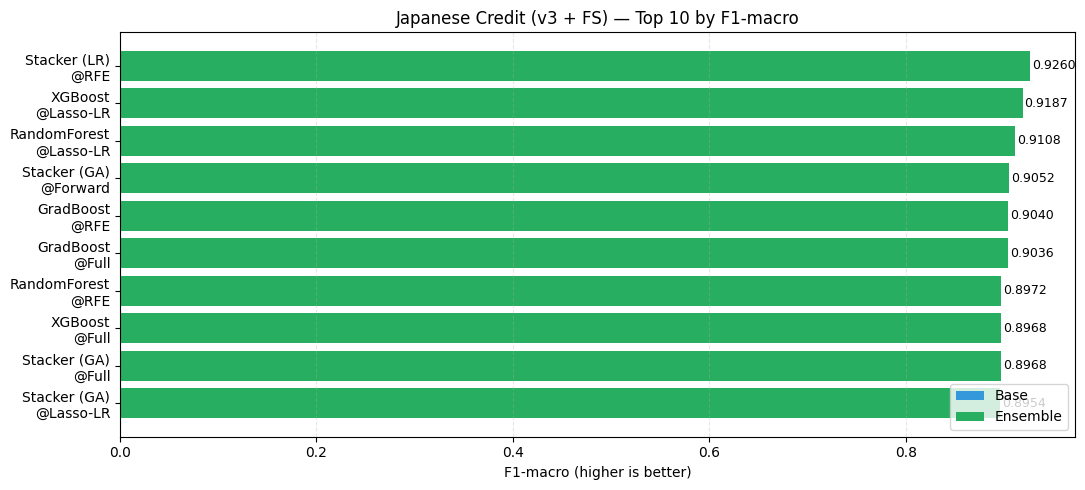

Saved → /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/results/japanese_v3_top10_f1macro.png


In [41]:
top = df_all.head(10).copy()
labels = [f'{m}\n@{fs}' for m, fs in zip(top['Model'], top['FS'])]
colors = {'Base': '#3498db', 'Ensemble': '#27ae60'}
bar_colors = [colors[c] for c in top['Category']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(top)), top['F1-macro'], color=bar_colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('F1-macro (higher is better)')
ax.set_title('Japanese Credit (v3 + FS) — Top 10 by F1-macro')
for i, v in enumerate(top['F1-macro']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3, ls='--')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=colors[k], label=k) for k in colors], loc='lower right')
plt.tight_layout()
plot_path = RESULTS_DIR / f'{RUN_TAG}_top10_f1macro.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {plot_path}')

### §6.4 — Winner declaration

In [42]:
winner = df_all.iloc[0]
print('=' * 70); print('  WINNER on Japanese Credit (by F1-macro):'); print('=' * 70)
print(f'  Model:    {winner["Model"]}')
print(f'  Category: {winner["Category"]}')
print(f'  FS:       {winner["FS"]}  ({winner["n_feat"]} features)')
print(f'  Accuracy: {winner["Accuracy"]:.4f}')
print(f'  F1:       {winner["F1"]:.4f}')
print(f'  F1-macro: {winner["F1-macro"]:.4f}')
print(f'  AUC:      {winner["AUC"]:.4f}')
print(f'  thr:      {winner["thr"]:.2f}')

stackers = df_all[df_all['Model'].str.startswith('Stacker')]
non_stacker = df_all[~df_all['Model'].str.startswith('Stacker')]
if len(stackers) and len(non_stacker):
    best_stacker = stackers.iloc[0]
    best_non_stacker = non_stacker.iloc[0]
    margin = best_stacker['F1-macro'] - best_non_stacker['F1-macro']
    print(f'\n  Best Stacker:     {best_stacker["Model"]} @ {best_stacker["FS"]}  F1-macro={best_stacker["F1-macro"]:.4f}')
    print(f'  Best non-stacker: {best_non_stacker["Model"]} @ {best_non_stacker["FS"]}  F1-macro={best_non_stacker["F1-macro"]:.4f}')
    print(f'  Stacker margin:   {margin:+.4f} F1-macro')

  WINNER on Japanese Credit (by F1-macro):
  Model:    Stacker (LR)
  Category: Ensemble
  FS:       RFE  (18 features)
  Accuracy: 0.9275
  F1:       0.9153
  F1-macro: 0.9260
  AUC:      0.9698
  thr:      0.50

  Best Stacker:     Stacker (LR) @ RFE  F1-macro=0.9260
  Best non-stacker: XGBoost @ Lasso-LR  F1-macro=0.9187
  Stacker margin:   +0.0073 F1-macro


### §6.5 — Recap of every artefact saved

In [43]:
print('=' * 70); print('  Files saved by this notebook'); print('=' * 70)
for d in [SUBSETS_DIR, RESULTS_DIR]:
    for p in sorted(d.glob(f'{RUN_TAG}*')):
        size = p.stat().st_size
        print(f'  {p}  ({size:,} bytes)')

  Files saved by this notebook
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Forward.csv  (244,171 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Forward_features.csv  (150 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Full.csv  (511,670 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Full_features.csv  (298 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Lasso_LR.csv  (443,812 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_Lasso_LR_features.csv  (261 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_RFE.csv  (240,489 bytes)
  /content/drive/MyDrive/CreditRiskApp/tier2_predictive_models/fs_subsets/japanese_v3_FS_RFE_features.csv  (142 bytes)
  /content/drive/

## §7  Ten-measure evaluation (Chi et al., 2019)

This section adds the **ten credit-scoring measures** — Accuracy, AUC, Type I
error, Type II error, EMCC, G-Mean, Discriminant Power, F-Score, Kappa and
Youden's index — for every model and feature-selection variant.

The earlier model cells (§3, §5) store only Acc / F1 / F1-macro / AUC and
discard the predictions, so each model is **re-fitted here** to recover the full
confusion matrix. Every existing cell above is left unchanged.

### §7.1 — Ten-measure helper `ten_measures()`

In [44]:
# §7.1 -- Ten-measure suite (Chi et al., 2019).  1 = good = positive.
from sklearn.metrics import confusion_matrix

def ten_measures(y_true, y_pred, proba, cost_bad=5.0, cost_good=1.0):
    """Ten credit-scoring measures from labels + predicted probability."""
    y_true = np.asarray(y_true, int)
    y_pred = np.asarray(y_pred, int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    e = 1e-9
    total = tp + tn + fp + fn
    sens = tp / (tp + fn + e)          # sensitivity -- good applicants caught
    spec = tn / (tn + fp + e)          # specificity -- defaulters caught
    prec = tp / (tp + fp + e)
    type1 = fn / (tp + fn + e)         # Type I  -- good applicant wrongly rejected
    type2 = fp / (fp + tn + e)         # Type II -- defaulter wrongly approved
    pi_good = (tp + fn) / (total + e)
    pi_bad  = (tn + fp) / (total + e)
    sc  = min(max(sens, e), 1 - e)
    spc = min(max(spec, e), 1 - e)
    return dict(
        Accuracy = (tp + tn) / (total + e),
        AUC      = roc_auc_score(y_true, proba),
        TypeI    = type1,
        TypeII   = type2,
        EMCC     = cost_bad * pi_bad * type2 + cost_good * pi_good * type1,
        GMean    = np.sqrt(max(sens, 0.0) * max(spec, 0.0)),
        DP       = (np.sqrt(3) / np.pi) * (np.log(sc / (1 - sc))
                                           + np.log(spc / (1 - spc))),
        FScore   = 2 * prec * sens / (prec + sens + e),
        Kappa    = cohen_kappa_score(y_true, y_pred),
        Youden   = sens + spec - 1.0,
    )

print('ten_measures() ready -- Accuracy, AUC, Type I, Type II, EMCC, '
      'G-Mean, DP, F-Score, Kappa, Youden.')

ten_measures() ready -- Accuracy, AUC, Type I, Type II, EMCC, G-Mean, DP, F-Score, Kappa, Youden.


### §7.2 — `evaluate_ten()` and `sweep_ten()` (mirror `evaluate` / `sweep_single_model`)

In [45]:
# §7.2 -- mirror evaluate() / sweep_single_model() from §2, returning ten measures.
def evaluate_ten(model, X_tr, X_te, y_tr, y_te):
    """Fit on (X_tr, y_tr); predict on X_te; return the ten measures + thr.
    Same fit/predict and GHOST threshold logic as evaluate()."""
    model.fit(X_tr, y_tr)
    proba_test = model.predict_proba(X_te)[:, 1]
    if USE_GHOST:
        proba_train = model.predict_proba(X_tr)[:, 1]
        thr = ghostml.optimize_threshold_from_predictions(
            y_tr, proba_train, GHOST_THR, ThOpt_metrics='Kappa')
    else:
        thr = 0.5
    pred = (proba_test >= thr).astype(int)
    r = ten_measures(y_te, pred, proba_test)
    r['thr'] = thr
    return r

def sweep_ten(model_factory, name, category):
    """Run one model_factory across all 4 FS variants -- ten-measure version."""
    rows = []
    for fs_name, fs_idx in fs_methods.items():
        Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
        r = evaluate_ten(model_factory(), Xtr, Xte, y_train, y_test)
        r.update(model=name, category=category, fs=fs_name, n_features=len(fs_idx))
        rows.append(r)
        print(f'  [{category}] {name:<14s} | FS={fs_name:<8s} | '
              f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
              f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')
    return rows

print('evaluate_ten() and sweep_ten() ready.')

evaluate_ten() and sweep_ten() ready.


### §7.3 — Base models × 4 FS (ten measures)

In [46]:
# §7.3 -- Base models, ten measures (same factories as §3).
base_lr_10 = sweep_ten(
    lambda: maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    name='LogisticReg', category='Base')
base_knn_10 = sweep_ten(
    lambda: maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
    name='KNN', category='Base')
base_svm_10 = sweep_ten(
    lambda: maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                            probability=True, random_state=RANDOM_STATE)),
    name='SVM-RBF', category='Base')
base_dt_10 = sweep_ten(
    lambda: maybe_smote(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    name='DecisionTree', category='Base')

  [Base] LogisticReg    | FS=Full     | F-Score=0.8455  G-Mean=0.8612  AUC=0.9470  Kappa=0.7214
  [Base] LogisticReg    | FS=RFE      | F-Score=0.8730  G-Mean=0.8857  AUC=0.9529  Kappa=0.7665
  [Base] LogisticReg    | FS=Lasso-LR | F-Score=0.8387  G-Mean=0.8548  AUC=0.9468  Kappa=0.7072
  [Base] LogisticReg    | FS=Forward  | F-Score=0.8800  G-Mean=0.8923  AUC=0.9508  Kappa=0.7808
  [Base] KNN            | FS=Full     | F-Score=0.7500  G-Mean=0.7785  AUC=0.9184  Kappa=0.6060
  [Base] KNN            | FS=RFE      | F-Score=0.8364  G-Mean=0.8513  AUC=0.9505  Kappa=0.7301
  [Base] KNN            | FS=Lasso-LR | F-Score=0.7736  G-Mean=0.7983  AUC=0.9232  Kappa=0.6376
  [Base] KNN            | FS=Forward  | F-Score=0.8264  G-Mean=0.8445  AUC=0.9353  Kappa=0.6910
  [Base] SVM-RBF        | FS=Full     | F-Score=0.8264  G-Mean=0.8445  AUC=0.9236  Kappa=0.6910
  [Base] SVM-RBF        | FS=RFE      | F-Score=0.7586  G-Mean=0.7863  AUC=0.8910  Kappa=0.5844
  [Base] SVM-RBF        | FS=Lasso-LR | 

### §7.4 — Ensemble models × 4 FS (ten measures)

In [47]:
# §7.4 -- Ensemble models, ten measures (RF and XGB reuse the per-FS tuned models).
ens_rf_10 = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate_ten(tuned_rf[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='RandomForest', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_rf_10.append(r)
    print(f'  [Ensemble] RandomForest   | FS={fs_name:<8s} | '
          f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
          f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')

ens_gb_10 = sweep_ten(
    lambda: maybe_smote(GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
    name='GradBoost', category='Ensemble')

ens_xgb_10 = []
for fs_name, fs_idx in fs_methods.items():
    Xtr = X_train[:, fs_idx]; Xte = X_test[:, fs_idx]
    r = evaluate_ten(tuned_xgb[fs_name], Xtr, Xte, y_train, y_test)
    r.update(model='XGBoost', category='Ensemble', fs=fs_name, n_features=len(fs_idx))
    ens_xgb_10.append(r)
    print(f'  [Ensemble] XGBoost        | FS={fs_name:<8s} | '
          f'F-Score={r["FScore"]:.4f}  G-Mean={r["GMean"]:.4f}  '
          f'AUC={r["AUC"]:.4f}  Kappa={r["Kappa"]:.4f}')

  [Ensemble] RandomForest   | FS=Full     | F-Score=0.8618  G-Mean=0.8760  AUC=0.9606  Kappa=0.7507
  [Ensemble] RandomForest   | FS=RFE      | F-Score=0.8852  G-Mean=0.8971  AUC=0.9664  Kappa=0.7943
  [Ensemble] RandomForest   | FS=Lasso-LR | F-Score=0.8966  G-Mean=0.9051  AUC=0.9619  Kappa=0.8219
  [Ensemble] RandomForest   | FS=Forward  | F-Score=0.8689  G-Mean=0.8824  AUC=0.9505  Kappa=0.7650
  [Ensemble] GradBoost      | FS=Full     | F-Score=0.8889  G-Mean=0.8990  AUC=0.9630  Kappa=0.8074
  [Ensemble] GradBoost      | FS=RFE      | F-Score=0.8908  G-Mean=0.9014  AUC=0.9604  Kappa=0.8080
  [Ensemble] GradBoost      | FS=Lasso-LR | F-Score=0.8718  G-Mean=0.8842  AUC=0.9595  Kappa=0.7778
  [Ensemble] GradBoost      | FS=Forward  | F-Score=0.8718  G-Mean=0.8842  AUC=0.9446  Kappa=0.7778
  [Ensemble] XGBoost        | FS=Full     | F-Score=0.8833  G-Mean=0.8951  AUC=0.9606  Kappa=0.7936
  [Ensemble] XGBoost        | FS=RFE      | F-Score=0.8618  G-Mean=0.8760  AUC=0.9434  Kappa=0.7507


### §7.5 — Stacker × 4 FS (`run_stacker_v3_ten`, ten-measure copy of `run_stacker_v3`)

In [48]:
# §7.5 -- ten-measure copy of run_stacker_v3 (cell in §5b-2). Same 5 bases,
# 5 metas, same GHOST meta-threshold and winning-meta selection (by F1-macro);
# reports the ten-measure suite.
def run_stacker_v3_ten(Xtr, Xte, ytr, yte, fs_name):
    print(f'\n  -- Stacker @ FS={fs_name}  (ten-measure eval) --')
    base_models = {
        'RF'  : tuned_rf[fs_name],
        'GB'  : maybe_smote(GradientBoostingClassifier(
                   n_estimators=300, learning_rate=0.05, max_depth=5,
                   subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)),
        'XGB' : tuned_xgb[fs_name],
        'KNN' : maybe_smote(KNeighborsClassifier(n_neighbors=13, metric='manhattan')),
        'SVM' : maybe_smote(SVC(C=10.0, kernel='rbf', gamma='scale',
                                probability=True, random_state=RANDOM_STATE)),
    }
    oof_cols, test_cols = [], []
    for bname, bmodel in base_models.items():
        oof = cross_val_predict(bmodel, Xtr, ytr, cv=CV_FOLDS,
                                method='predict_proba')[:, 1]
        oof_cols.append(oof)
        bmodel.fit(Xtr, ytr)
        test_cols.append(bmodel.predict_proba(Xte)[:, 1])
    oof_probs  = np.column_stack(oof_cols)
    test_probs = np.column_stack(test_cols)

    best_lam = cv_best_lambda(oof_probs, ytr,
                              lambda_grid=[0.0005, 0.001, 0.002, 0.005, 0.01],
                              cv=5, n_gen=150)
    meta_models = {
        'LR'  : maybe_smote(LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
        'RF'  : maybe_smote(RandomForestClassifier(n_estimators=200, max_depth=5,
                                                   random_state=RANDOM_STATE)),
        'XGB' : maybe_smote(XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)),
        'MLP' : maybe_smote(MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                          alpha=0.001, max_iter=500, random_state=RANDOM_STATE)),
        'GA'  : maybe_smote(MaxAccLogit(lambda_reg=best_lam, n_gen=200,
                                        scoring='f1_macro', random_state=RANDOM_STATE)),
    }
    meta_eval = {}
    for mname, meta in meta_models.items():
        meta.fit(oof_probs, ytr)
        train_p = meta.predict_proba(oof_probs)[:, 1]
        proba   = meta.predict_proba(test_probs)[:, 1]
        if USE_GHOST:
            thr = ghostml.optimize_threshold_from_predictions(
                ytr, train_p, GHOST_THR, ThOpt_metrics='Kappa')
        else:
            thr = 0.5
        pred = (proba >= thr).astype(int)
        m = ten_measures(yte, pred, proba)
        m['f1_macro'] = f1_score(yte, pred, average='macro')
        m['thr'] = thr
        meta_eval[mname] = m
        print(f'    meta {mname:<5s}  F-Score={m["FScore"]:.4f}  G-Mean={m["GMean"]:.4f}  '
              f'AUC={m["AUC"]:.4f}  Kappa={m["Kappa"]:.4f}  thr={thr:.2f}')
    best_meta = max(meta_eval, key=lambda k: meta_eval[k]['f1_macro'])
    r = {k: v for k, v in meta_eval[best_meta].items() if k != 'f1_macro'}
    r.update(model=f'Stacker ({best_meta})', category='Ensemble',
             fs=fs_name, n_features=Xtr.shape[1])
    print(f'    -> winning meta: {best_meta}  (F-Score={r["FScore"]:.4f})')
    return r

print('run_stacker_v3_ten() ready.')

run_stacker_v3_ten() ready.


In [49]:
# §7.5 -- run the ten-measure stacker once per FS variant.
stk_full_10  = run_stacker_v3_ten(X_train[:, fs_methods['Full']],
                                  X_test[:,  fs_methods['Full']],     y_train, y_test, 'Full')
stk_rfe_10   = run_stacker_v3_ten(X_train[:, fs_methods['RFE']],
                                  X_test[:,  fs_methods['RFE']],      y_train, y_test, 'RFE')
stk_lasso_10 = run_stacker_v3_ten(X_train[:, fs_methods['Lasso-LR']],
                                  X_test[:,  fs_methods['Lasso-LR']], y_train, y_test, 'Lasso-LR')
stk_fwd_10   = run_stacker_v3_ten(X_train[:, fs_methods['Forward']],
                                  X_test[:,  fs_methods['Forward']],  y_train, y_test, 'Forward')


  -- Stacker @ FS=Full  (ten-measure eval) --
    meta LR     F-Score=0.8739  G-Mean=0.8866  AUC=0.9653  Kappa=0.7785  thr=0.50
    meta RF     F-Score=0.8621  G-Mean=0.8755  AUC=0.9568  Kappa=0.7625  thr=0.50
    meta XGB    F-Score=0.8448  G-Mean=0.8606  AUC=0.9522  Kappa=0.7328  thr=0.50
    meta MLP    F-Score=0.8673  G-Mean=0.8786  AUC=0.9606  Kappa=0.7762  thr=0.50
    meta GA     F-Score=0.8833  G-Mean=0.8951  AUC=0.9644  Kappa=0.7936  thr=0.50
    -> winning meta: GA  (F-Score=0.8833)

  -- Stacker @ FS=RFE  (ten-measure eval) --
    meta LR     F-Score=0.9153  G-Mean=0.9224  AUC=0.9698  Kappa=0.8521  thr=0.50
    meta RF     F-Score=0.8772  G-Mean=0.8875  AUC=0.9565  Kappa=0.7915  thr=0.50
    meta XGB    F-Score=0.8889  G-Mean=0.8990  AUC=0.9632  Kappa=0.8074  thr=0.50
    meta MLP    F-Score=0.9153  G-Mean=0.9224  AUC=0.9553  Kappa=0.8521  thr=0.50
    meta GA     F-Score=0.8649  G-Mean=0.8755  AUC=0.9627  Kappa=0.7754  thr=0.50
    -> winning meta: LR  (F-Score=0.9153)

  

### §7.6 — Ten-measure results table + save CSV

In [50]:
# §7.6 -- combine, sort, display and save the ten-measure results.
all_ten = (base_lr_10 + base_knn_10 + base_svm_10 + base_dt_10
           + ens_rf_10 + ens_gb_10 + ens_xgb_10
           + [stk_full_10, stk_rfe_10, stk_lasso_10, stk_fwd_10])

df_ten = pd.DataFrame(all_ten)[
    ['category', 'model', 'fs', 'n_features',
     'Accuracy', 'AUC', 'TypeI', 'TypeII', 'EMCC',
     'GMean', 'DP', 'FScore', 'Kappa', 'Youden', 'thr']
]
df_ten.columns = ['Category', 'Model', 'FS', 'n_feat',
                  'Accuracy', 'AUC', 'Type I', 'Type II', 'EMCC',
                  'G-Mean', 'DP', 'F-Score', 'Kappa', 'Youden', 'thr']
for c in ['Accuracy', 'AUC', 'Type I', 'Type II', 'EMCC',
          'G-Mean', 'DP', 'F-Score', 'Kappa', 'Youden']:
    df_ten[c] = df_ten[c].round(4)
df_ten['thr'] = df_ten['thr'].round(2)
df_ten = df_ten.sort_values('F-Score', ascending=False).reset_index(drop=True)

print('=' * 110)
print('  §7 TEN-MEASURE EVALUATION -- every model x every FS (sorted by F-Score)')
print('=' * 110)
print(df_ten.to_string(index=False))
print('\nHigher is better EXCEPT Type I, Type II, EMCC (lower is better).')
save_csv(df_ten, RESULTS_DIR / f'{RUN_TAG}_ten_measure_results.csv')

  §7 TEN-MEASURE EVALUATION -- every model x every FS (sorted by F-Score)
Category        Model       FS  n_feat  Accuracy    AUC  Type I  Type II   EMCC  G-Mean     DP  F-Score  Kappa  Youden  thr
Ensemble Stacker (LR)      RFE      18    0.9275 0.9698  0.1148   0.0390 0.1594  0.9224 2.8937   0.9153 0.8521  0.8463  0.5
Ensemble      XGBoost Lasso-LR      32    0.9203 0.9642  0.1148   0.0519 0.1957  0.9161 2.7276   0.9076 0.8376  0.8333  0.5
Ensemble Stacker (GA)  Forward      18    0.9058 0.9630  0.0656   0.1169 0.3551  0.9084 2.5797   0.8976 0.8106  0.8175  0.5
Ensemble RandomForest Lasso-LR      32    0.9130 0.9619  0.1475   0.0390 0.1739  0.9051 2.7343   0.8966 0.8219  0.8135  0.5
Ensemble    GradBoost      RFE      18    0.9058 0.9604  0.1311   0.0649 0.2391  0.9014 2.5130   0.8908 0.8080  0.8039  0.5
Ensemble    GradBoost     Full      37    0.9058 0.9630  0.1475   0.0519 0.2101  0.8990 2.5682   0.8889 0.8074  0.8005  0.5
Ensemble RandomForest      RFE      18    0.8986 0.9664  0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>